<a href="https://colab.research.google.com/github/BeanQueso/dsrp/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the tools I will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [ ]:
# Load the 2024 Stack Overflow Developer Survey
df = pd.read_csv("survey_results_public.csv")
df.shape

(65437, 114)

In [ ]:
# Look at the first five responses
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [ ]:
# Check the column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [ ]:
# These are the survey columns I need for this question
columns = [
    "ResponseId", "MainBranch", "AISelect", "AIToolCurrently Using",
    "AIAcc", "AIComplex", "AIChallenges", "WorkExp", "Age",
    "DevType", "OrgSize", "Industry", "RemoteWork"
]

df[columns].isna().sum().to_frame("Missing values")

,Missing values
ResponseId,0
MainBranch,0
AISelect,4530
AIToolCurrently Using,30365
AIAcc,28135
AIComplex,28416
AIChallenges,27906
WorkExp,35779
Age,0
DevType,5992


In [ ]:
# First keep people who identify as professional developers
professionals = df[
    df["MainBranch"] == "I am a developer by profession"
].copy()

professionals.shape

(50207, 114)

In [ ]:
# Then keep current AI users who reported at least one AI task
ai = professionals[
    (professionals["AISelect"] == "Yes")
    & professionals["AIToolCurrently Using"].notna()
].copy()

ai.shape

(27756, 114)

In [ ]:
# Count each task separately because respondents could select several
task_counts = (
    ai["AIToolCurrently Using"]
    .str.split(";")
    .explode()
    .value_counts()
)

task_counts

AIToolCurrently Using
Writing code                            23525
Search for answers                      19129
Debugging and getting help              15749
Documenting code                        11777
Generating content or synthetic data    10106
Learning about a codebase                8428
Testing code                             8231
Committing and reviewing code            3596
Project planning                         3139
Predictive analytics                     1360
Deployment and monitoring                1198
Other (please specify):                   321
Name: count, dtype: int64

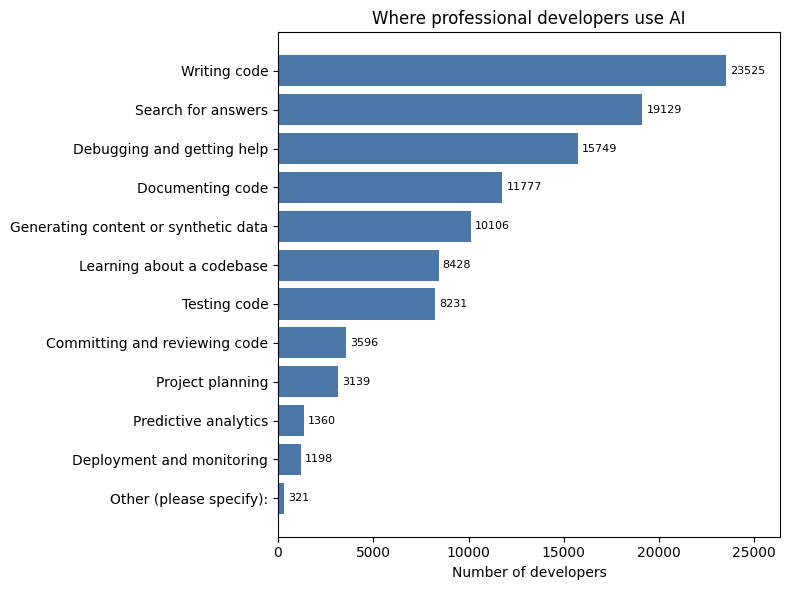

In [ ]:
# Plot where the developers in this sample use AI
plot_tasks = task_counts.sort_values()
plt.figure(figsize=(8, 6))
bars = plt.barh(plot_tasks.index, plot_tasks.values, color="#4C78A8")
plt.bar_label(bars, padding=3, fontsize=8)
plt.title("Where professional developers use AI")
plt.xlabel("Number of developers")
plt.xlim(0, plot_tasks.max() * 1.12)
plt.tight_layout()
plt.show()

In [ ]:
# Use code review and deployment as the primary outcome
# Predictive analytics is kept separate because it is a different kind of task
primary_tasks = {
    "Committing and reviewing code",
    "Deployment and monitoring"
}

primary_tasks

{'Committing and reviewing code', 'Deployment and monitoring'}

In [ ]:
# Make the outcome: 1 means AI is used in review or deployment
task_sets = ai["AIToolCurrently Using"].str.split(";").apply(set)
ai["ReviewDeploymentUse"] = task_sets.apply(
    lambda tasks: int(bool(tasks & primary_tasks))
)

ai["ReviewDeploymentUse"].value_counts()

ReviewDeploymentUse
0    23629
1     4127
Name: count, dtype: int64

In [ ]:
# Check how common the primary outcome is
primary_count = ai["ReviewDeploymentUse"].sum()
primary_percent = ai["ReviewDeploymentUse"].mean() * 100

print("Developers using AI in review or deployment:", primary_count)
print("Percent of this sample:", round(primary_percent, 1))

Developers using AI in review or deployment: 4127
Percent of this sample: 14.9


In [ ]:
# Put the five trust answers in their natural order
trust_order = [
    "Highly distrust",
    "Somewhat distrust",
    "Neither trust nor distrust",
    "Somewhat trust",
    "Highly trust"
]

ai["AIAcc"].value_counts(dropna=False).reindex(trust_order + [np.nan])

AIAcc
Highly distrust                2249
Somewhat distrust              6437
Neither trust nor distrust     7538
Somewhat trust                10907
Highly trust                    611
NaN                              14
Name: count, dtype: int64

In [ ]:
# Calculate the review-or-deployment use rate at each trust level
trust_rates = (
    ai.dropna(subset=["AIAcc"])
    .groupby("AIAcc")["ReviewDeploymentUse"]
    .agg(["count", "mean"])
    .reindex(trust_order)
)
trust_rates["Percent"] = trust_rates["mean"] * 100

trust_rates[["count", "Percent"]].round(1)

,count,Percent
AIAcc,,
Highly distrust,2249,8.4
Somewhat distrust,6437,9.5
Neither trust nor distrust,7538,15.0
Somewhat trust,10907,18.4
Highly trust,611,30.8


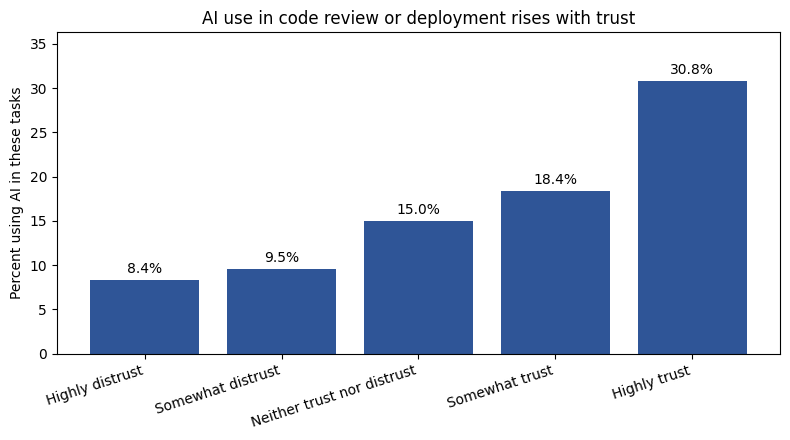

In [ ]:
# This is the first main figure in the presentation
plt.figure(figsize=(8, 4.5))
bars = plt.bar(trust_rates.index, trust_rates["Percent"], color="#2F5597")
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.title("AI use in code review or deployment rises with trust")
plt.ylabel("Percent using AI in these tasks")
plt.xticks(rotation=18, ha="right")
plt.ylim(0, trust_rates["Percent"].max() * 1.18)
plt.tight_layout()
plt.savefig("trust_vs_review_deployment_use.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Mark respondents who reported missing company policies for AI security risks
policy_phrase = "right policies in place to reduce security risks"
ai["SecurityPolicyGap"] = ai["AIChallenges"].str.contains(
    policy_phrase, regex=False
).astype("Int64")

ai["SecurityPolicyGap"].value_counts(dropna=False)

SecurityPolicyGap
0       16388
1        7736
<NA>     3632
Name: count, dtype: Int64

In [ ]:
# Compare raw use rates for people who did and did not report this policy gap
policy_rates = (
    ai.dropna(subset=["SecurityPolicyGap"])
    .groupby("SecurityPolicyGap")["ReviewDeploymentUse"]
    .agg(["count", "mean"])
)
policy_rates["Percent"] = policy_rates["mean"] * 100

policy_rates.round(3)

,count,mean,Percent
SecurityPolicyGap,,,
0,16388,0.143,14.309
1,7736,0.150,15.047


In [ ]:
# Make a table for the trust chi-square test
trust_data = ai.dropna(subset=["AIAcc"])
trust_table = pd.crosstab(
    trust_data["AIAcc"], trust_data["ReviewDeploymentUse"]
).reindex(trust_order)

trust_table

ReviewDeploymentUse,0,1
AIAcc,,
Highly distrust,2061,188
Somewhat distrust,5823,614
Neither trust nor distrust,6406,1132
Somewhat trust,8904,2003
Highly trust,423,188


In [ ]:
# Test whether trust level and review-or-deployment use are independent
trust_chi2, trust_p, trust_dof, trust_expected = chi2_contingency(trust_table)

print("Chi-square:", round(trust_chi2, 2))
print("Degrees of freedom:", trust_dof)
print("p-value:", trust_p)

Chi-square: 447.21
Degrees of freedom: 4
p-value: 1.738765428319549e-95


In [ ]:
# Cramer's V measures the strength of that relationship from 0 to 1
trust_n = trust_table.to_numpy().sum()
trust_v = np.sqrt(
    trust_chi2 / (trust_n * min(trust_table.shape[0] - 1, trust_table.shape[1] - 1))
)

print("Cramer's V:", round(trust_v, 3))

Cramer's V: 0.127


In [ ]:
# Repeat the same test for the reported security-policy gap
policy_data = ai.dropna(subset=["SecurityPolicyGap"])
policy_table = pd.crosstab(
    policy_data["SecurityPolicyGap"], policy_data["ReviewDeploymentUse"]
)

policy_table

ReviewDeploymentUse,0,1
SecurityPolicyGap,,
0,14043,2345
1,6572,1164


In [ ]:
# Calculate the policy test and its effect size
policy_chi2, policy_p, policy_dof, policy_expected = chi2_contingency(policy_table)
policy_n = policy_table.to_numpy().sum()
policy_v = np.sqrt(
    policy_chi2 / (policy_n * min(policy_table.shape[0] - 1, policy_table.shape[1] - 1))
)

print("Chi-square:", round(policy_chi2, 2))
print("p-value:", f"{policy_p:.6f}")
print("Cramer's V:", round(policy_v, 3))

Chi-square: 2.24
p-value: 0.134541
Cramer's V: 0.01


In [ ]:
# Create two related challenge flags to use as controls
ai["LacksCompanyContext"] = ai["AIChallenges"].str.contains(
    "lack context of codebase", case=False, regex=False
).astype("Int64")
ai["CreatesMoreWork"] = ai["AIChallenges"].str.contains(
    "create more work", case=False, regex=False
).astype("Int64")

In [ ]:
# The regression needs complete trust, complexity, and challenge answers
model_data = ai.dropna(
    subset=["AIAcc", "AIComplex", "AIChallenges"]
).copy()

model_data.shape

(24047, 118)

In [ ]:
# Keep missing demographic answers as their own category instead of deleting them
model_data["WorkExp"] = model_data["WorkExp"].fillna(
    model_data["WorkExp"].median()
)

for column in ["Age", "DevType", "OrgSize", "Industry", "RemoteWork"]:
    model_data[column] = model_data[column].fillna("Missing")

model_data[["WorkExp", "Age", "DevType", "OrgSize", "Industry", "RemoteWork"]].isna().sum()

WorkExp       0
Age           0
DevType       0
OrgSize       0
Industry      0
RemoteWork    0
dtype: int64

In [ ]:
# Fit one explanatory logistic regression with neutral trust as the reference
formula = '''ReviewDeploymentUse ~
C(AIAcc, Treatment(reference='Neither trust nor distrust'))
+ C(AIComplex, Treatment(reference='Neither good or bad at handling complex tasks'))
+ SecurityPolicyGap + LacksCompanyContext + CreatesMoreWork
+ WorkExp + C(Age) + C(DevType) + C(OrgSize) + C(Industry) + C(RemoteWork)
'''

model = smf.glm(
    formula=formula,
    data=model_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# Convert coefficients into odds ratios and 95% confidence intervals
results = pd.DataFrame({
    "Term": model.params.index,
    "Odds ratio": np.exp(model.params),
    "CI low": np.exp(model.conf_int()[0]),
    "CI high": np.exp(model.conf_int()[1]),
    "p-value": model.pvalues
})

results.head()

,Term,Odds ratio,CI low,CI high,p-value
Intercept,Intercept,0.154925,0.094129,0.254988,2.213039e-13
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly distrust]","C(AIAcc, Treatment(reference='Neither trust no...",0.640750,0.532663,0.770771,2.334468e-06
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]","C(AIAcc, Treatment(reference='Neither trust no...",1.616715,1.283113,2.037052,4.618818e-05
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat distrust]","C(AIAcc, Treatment(reference='Neither trust no...",0.703667,0.626800,0.789961,2.605523e-09
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat trust]","C(AIAcc, Treatment(reference='Neither trust no...",1.088168,0.994879,1.190204,6.464601e-02


In [ ]:
# Keep only the trust and policy results that answer the research question
labels = {
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly distrust]": "Highly distrust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat distrust]": "Somewhat distrust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat trust]": "Somewhat trust vs. neutral",
    "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]": "Highly trust vs. neutral",
    "SecurityPolicyGap": "Reports missing security policies"
}

main_results = results[results["Term"].isin(labels)].copy()
main_results["Relationship"] = main_results["Term"].map(labels)
main_results[["Relationship", "Odds ratio", "CI low", "CI high", "p-value"]].round(3)

,Relationship,Odds ratio,CI low,CI high,p-value
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly distrust]",Highly distrust vs. neutral,0.641,0.533,0.771,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]",Highly trust vs. neutral,1.617,1.283,2.037,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat distrust]",Somewhat distrust vs. neutral,0.704,0.627,0.790,0.000
"C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Somewhat trust]",Somewhat trust vs. neutral,1.088,0.995,1.190,0.065
SecurityPolicyGap,Reports missing security policies,1.023,0.946,1.107,0.564


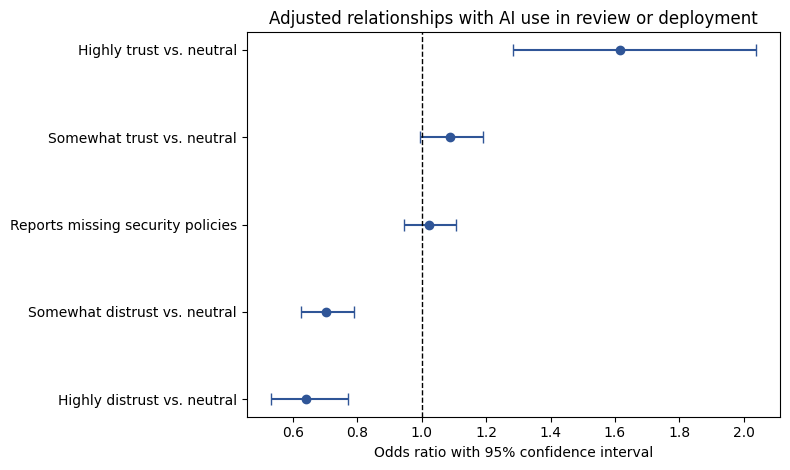

In [ ]:
# This is the second main figure in the presentation
odds_plot = main_results.sort_values("Odds ratio")
x_error = [
    odds_plot["Odds ratio"] - odds_plot["CI low"],
    odds_plot["CI high"] - odds_plot["Odds ratio"]
]

plt.figure(figsize=(8, 4.8))
plt.errorbar(odds_plot["Odds ratio"], odds_plot["Relationship"],
             xerr=x_error, fmt="o", color="#2F5597", capsize=4)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.title("Adjusted relationships with AI use in review or deployment")
plt.xlabel("Odds ratio with 95% confidence interval")
plt.tight_layout()
plt.savefig("adjusted_odds_ratios_review_deployment.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Use a holdout sample to check how well the same model separates the two outcomes
train_data, test_data = train_test_split(
    model_data, test_size=0.20, random_state=42,
    stratify=model_data["ReviewDeploymentUse"]
)

validation_model = smf.glm(
    formula=formula, data=train_data, family=sm.families.Binomial()
).fit()
test_probability = validation_model.predict(test_data)

print("Holdout ROC-AUC:", round(roc_auc_score(test_data["ReviewDeploymentUse"], test_probability), 3))

Holdout ROC-AUC: 0.615


In [ ]:
# Put the two statistical tests next to each other
test_summary = pd.DataFrame({
    "Relationship": ["Trust level", "Reported security-policy gap"],
    "Chi-square": [f"{trust_chi2:.2f}", f"{policy_chi2:.2f}"],
    "p-value": [f"{trust_p:.2e}", f"{policy_p:.6f}"],
    "Cramer's V": [f"{trust_v:.3f}", f"{policy_v:.3f}"]
})

test_summary

,Relationship,Chi-square,p-value,Cramer's V
0,Trust level,447.21,1.74e-95,0.127
1,Reported security-policy gap,2.24,0.134541,0.010


In [ ]:
# Sensitivity checks: see whether the main conclusion depends on my choices
# I will change one reasonable decision at a time and compare the results.

In [ ]:
# Make broader and task-specific versions of the outcome
ai["BroadTaskUse"] = task_sets.apply(lambda x: int(bool(x & {
    "Committing and reviewing code", "Deployment and monitoring",
    "Predictive analytics"
})))
ai["CodeReviewUse"] = task_sets.apply(
    lambda x: int("Committing and reviewing code" in x)
)
ai["DeploymentUse"] = task_sets.apply(
    lambda x: int("Deployment and monitoring" in x)
)
ai["PredictiveUse"] = task_sets.apply(
    lambda x: int("Predictive analytics" in x)
)

outcome_columns = [
    "ReviewDeploymentUse", "BroadTaskUse", "CodeReviewUse",
    "DeploymentUse", "PredictiveUse"
]
(ai[outcome_columns].mean() * 100).round(1)

ReviewDeploymentUse    14.9
BroadTaskUse           17.3
CodeReviewUse          13.0
DeploymentUse           4.3
PredictiveUse           4.9
dtype: float64

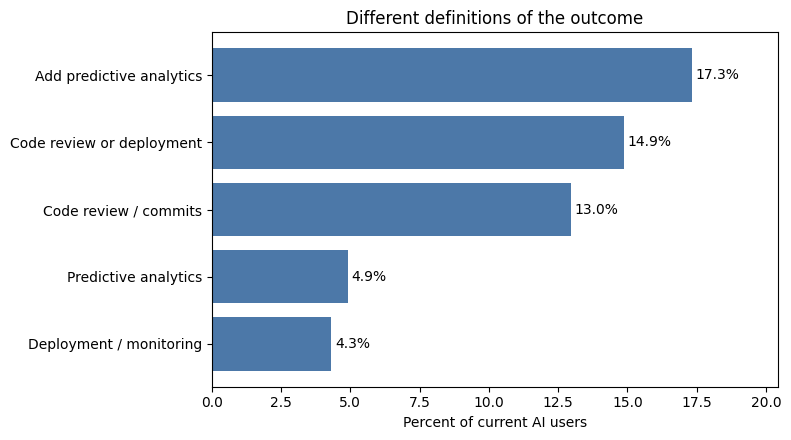

In [ ]:
# Plot how common each version of the outcome is
outcome_names = {
    "ReviewDeploymentUse": "Code review or deployment",
    "BroadTaskUse": "Add predictive analytics",
    "CodeReviewUse": "Code review / commits",
    "DeploymentUse": "Deployment / monitoring",
    "PredictiveUse": "Predictive analytics"
}

outcome_rates = (ai[outcome_columns].mean() * 100).sort_values()
plt.figure(figsize=(8, 4.5))
bars = plt.barh(
    [outcome_names[x] for x in outcome_rates.index],
    outcome_rates.values,
    color="#4C78A8"
)
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.xlabel("Percent of current AI users")
plt.title("Different definitions of the outcome")
plt.xlim(0, outcome_rates.max() * 1.18)
plt.tight_layout()
plt.show()

In [ ]:
# Add the alternative outcomes to the same rows used by the main model
for outcome in outcome_columns[1:]:
    model_data[outcome] = ai.loc[model_data.index, outcome]

model_data[outcome_columns].mean().mul(100).round(1)

ReviewDeploymentUse    14.6
BroadTaskUse           17.0
CodeReviewUse          12.7
DeploymentUse           4.2
PredictiveUse           4.7
dtype: float64

In [ ]:
# Refit the full model for each alternative outcome
alternative_models = {}

for outcome in outcome_columns[1:]:
    alternative_formula = formula.replace("ReviewDeploymentUse", outcome, 1)
    alternative_models[outcome] = smf.glm(
        formula=alternative_formula,
        data=model_data,
        family=sm.families.Binomial()
    ).fit(cov_type="HC3")

list(alternative_models)

['BroadTaskUse', 'CodeReviewUse', 'DeploymentUse', 'PredictiveUse']

In [ ]:
# Use a small function to pull the same result from several models
trust_term = "C(AIAcc, Treatment(reference='Neither trust nor distrust'))[T.Highly trust]"
policy_term = "SecurityPolicyGap"

def odds_ratio_row(fitted_model, term, analysis, relationship):
    low, high = fitted_model.conf_int().loc[term]
    return {
        "Analysis": analysis,
        "Relationship": relationship,
        "Odds ratio": np.exp(fitted_model.params[term]),
        "CI low": np.exp(low),
        "CI high": np.exp(high),
        "p-value": fitted_model.pvalues[term]
    }

In [ ]:
# Compare trust and the policy gap across the outcome definitions
outcome_rows = []

for outcome, fitted_model in alternative_models.items():
    name = outcome_names[outcome]
    outcome_rows.append(odds_ratio_row(
        fitted_model, trust_term, name, "Highly trust vs. neutral"
    ))
    outcome_rows.append(odds_ratio_row(
        fitted_model, policy_term, name, "Reported policy gap"
    ))

outcome_sensitivity = pd.DataFrame(outcome_rows)
outcome_sensitivity.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Add predictive analytics,Highly trust vs. neutral,1.576,1.260,1.972,0.000
1,Add predictive analytics,Reported policy gap,1.032,0.958,1.111,0.409
2,Code review / commits,Highly trust vs. neutral,1.469,1.153,1.872,0.002
3,Code review / commits,Reported policy gap,1.002,0.922,1.090,0.955
4,Deployment / monitoring,Highly trust vs. neutral,2.517,1.836,3.451,0.000
5,Deployment / monitoring,Reported policy gap,1.126,0.981,1.294,0.092
6,Predictive analytics,Highly trust vs. neutral,2.125,1.556,2.901,0.000
7,Predictive analytics,Reported policy gap,1.171,1.030,1.331,0.016


In [ ]:
# Correct the four exploratory policy tests for multiple comparisons
from statsmodels.stats.multitest import multipletests

policy_task_tests = outcome_sensitivity[
    outcome_sensitivity["Relationship"] == "Reported policy gap"
].copy()
policy_task_tests["Adjusted p-value"] = multipletests(
    policy_task_tests["p-value"], method="fdr_bh"
)[1]

policy_task_tests[[
    "Analysis", "Odds ratio", "CI low", "CI high",
    "p-value", "Adjusted p-value"
]].round(3)

,Analysis,Odds ratio,CI low,CI high,p-value,Adjusted p-value
1,Add predictive analytics,1.032,0.958,1.111,0.409,0.545
3,Code review / commits,1.002,0.922,1.090,0.955,0.955
5,Deployment / monitoring,1.126,0.981,1.294,0.092,0.184
7,Predictive analytics,1.171,1.030,1.331,0.016,0.064


In [ ]:
# Next make a complete-case dataset with no imputation or Missing categories
complete_columns = [
    "AIAcc", "AIComplex", "AIChallenges", "WorkExp", "Age",
    "DevType", "OrgSize", "Industry", "RemoteWork"
]

complete_data = ai.dropna(subset=complete_columns).copy()
print("Rows in the main adjusted model:", len(model_data))
print("Rows in the complete-case model:", len(complete_data))

Rows in the main adjusted model: 24047
Rows in the complete-case model: 14473


In [ ]:
# Fit the same full model using only complete rows
complete_case_model = smf.glm(
    formula=formula,
    data=complete_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

complete_case_results = pd.DataFrame([
    odds_ratio_row(complete_case_model, trust_term,
                   "Complete cases", "Highly trust vs. neutral"),
    odds_ratio_row(complete_case_model, policy_term,
                   "Complete cases", "Reported policy gap")
])
complete_case_results.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Complete cases,Highly trust vs. neutral,1.931,1.431,2.606,0.000
1,Complete cases,Reported policy gap,1.037,0.937,1.147,0.483


In [ ]:
# Try treating trust as one ordered score from -2 to 2
trust_scores = dict(zip(trust_order, [-2, -1, 0, 1, 2]))
ordinal_data = model_data.copy()
ordinal_data["TrustScore"] = ordinal_data["AIAcc"].map(trust_scores)

trust_factor = "C(AIAcc, Treatment(reference='Neither trust nor distrust'))"
ordinal_formula = formula.replace(trust_factor, "TrustScore")

ordinal_model = smf.glm(
    formula=ordinal_formula,
    data=ordinal_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# This odds ratio is for moving up one trust category
ordinal_low, ordinal_high = ordinal_model.conf_int().loc["TrustScore"]

pd.DataFrame({
    "Odds ratio per trust step": [np.exp(ordinal_model.params["TrustScore"])],
    "CI low": [np.exp(ordinal_low)],
    "CI high": [np.exp(ordinal_high)],
    "p-value": [ordinal_model.pvalues["TrustScore"]]
}).round(3)

,Odds ratio per trust step,CI low,CI high,p-value
0,1.222,1.169,1.278,0.0


In [ ]:
# Also simplify trust into distrust, neutral, and trust
trust_three_groups = {
    "Highly distrust": "Distrust",
    "Somewhat distrust": "Distrust",
    "Neither trust nor distrust": "Neutral",
    "Somewhat trust": "Trust",
    "Highly trust": "Trust"
}

three_group_data = model_data.copy()
three_group_data["TrustGroup"] = three_group_data["AIAcc"].map(trust_three_groups)
three_group_formula = formula.replace(
    trust_factor,
    "C(TrustGroup, Treatment(reference='Neutral'))"
)

three_group_model = smf.glm(
    formula=three_group_formula,
    data=three_group_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# Compare the two combined trust groups with neutral
three_group_terms = {
    "C(TrustGroup, Treatment(reference='Neutral'))[T.Distrust]": "Distrust vs. neutral",
    "C(TrustGroup, Treatment(reference='Neutral'))[T.Trust]": "Trust vs. neutral"
}

three_group_rows = []
for term, label in three_group_terms.items():
    three_group_rows.append(
        odds_ratio_row(three_group_model, term, "Three trust groups", label)
    )

pd.DataFrame(three_group_rows).round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Three trust groups,Distrust vs. neutral,0.692,0.62,0.773,0.000
1,Three trust groups,Trust vs. neutral,1.105,1.01,1.207,0.029


In [ ]:
# Compare smaller adjustment sets with the full model
minimal_formula = f"""ReviewDeploymentUse ~ {trust_factor}
+ SecurityPolicyGap"""

basic_formula = f"""ReviewDeploymentUse ~ {trust_factor}
+ SecurityPolicyGap + WorkExp + C(Age)"""

minimal_model = smf.glm(
    minimal_formula, data=model_data, family=sm.families.Binomial()
).fit(cov_type="HC3")

basic_model = smf.glm(
    basic_formula, data=model_data, family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# See whether adding all controls changes the two main estimates
adjustment_rows = []

for name, fitted_model in {
    "Trust and policy only": minimal_model,
    "Add experience and age": basic_model,
    "Full adjustment": model
}.items():
    adjustment_rows.append(odds_ratio_row(
        fitted_model, trust_term, name, "Highly trust vs. neutral"
    ))
    adjustment_rows.append(odds_ratio_row(
        fitted_model, policy_term, name, "Reported policy gap"
    ))

adjustment_sensitivity = pd.DataFrame(adjustment_rows)
adjustment_sensitivity.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Trust and policy only,Highly trust vs. neutral,2.733,2.216,3.370,0.000
1,Trust and policy only,Reported policy gap,1.051,0.974,1.135,0.200
2,Add experience and age,Highly trust vs. neutral,2.757,2.231,3.406,0.000
3,Add experience and age,Reported policy gap,1.046,0.969,1.130,0.249
4,Full adjustment,Highly trust vs. neutral,1.617,1.283,2.037,0.000
5,Full adjustment,Reported policy gap,1.023,0.946,1.107,0.564


In [ ]:
# Check the range of professional experience before changing it
model_data["WorkExp"].describe(percentiles=[0.95, 0.99])

count    24047.000000
mean         9.495155
std          6.752474
min          0.000000
50%          8.000000
95%         25.000000
99%         35.000000
max         50.000000
Name: WorkExp, dtype: float64

In [ ]:
# Cap experience at its 99th percentile and refit the full model
experience_cap = model_data["WorkExp"].quantile(0.99)
capped_data = model_data.copy()
capped_data["WorkExp"] = capped_data["WorkExp"].clip(upper=experience_cap)

capped_experience_model = smf.glm(
    formula=formula,
    data=capped_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

print("99th percentile used as the cap:", experience_cap)

99th percentile used as the cap: 35.0


In [ ]:
# Compare the main estimates before and after the experience cap
capped_results = pd.DataFrame([
    odds_ratio_row(capped_experience_model, trust_term,
                   "Experience capped", "Highly trust vs. neutral"),
    odds_ratio_row(capped_experience_model, policy_term,
                   "Experience capped", "Reported policy gap")
])
capped_results.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Experience capped,Highly trust vs. neutral,1.617,1.283,2.037,0.000
1,Experience capped,Reported policy gap,1.023,0.946,1.107,0.563


In [ ]:
# Count unanswered AI-challenge questions instead of treating them as No
print("Answered AIChallenges:", ai["AIChallenges"].notna().sum())
print("Missing AIChallenges:", ai["AIChallenges"].isna().sum())

ai.groupby(ai["AIChallenges"].isna())["ReviewDeploymentUse"].agg(
    count="count", percent="mean"
).assign(percent=lambda x: x["percent"] * 100).round(1)

Answered AIChallenges: 24124
Missing AIChallenges: 3632


,count,percent
AIChallenges,,
False,24124,14.5
True,3632,17.0


In [ ]:
# Prepare two policy datasets: answered only, and missing counted as No
policy_answered = ai.dropna(subset=["AIAcc", "AIChallenges"]).copy()
policy_missing_as_no = ai.dropna(subset=["AIAcc"]).copy()

for current_data in [policy_answered, policy_missing_as_no]:
    current_data["WorkExp"] = current_data["WorkExp"].fillna(
        current_data["WorkExp"].median()
    )
    current_data["Age"] = current_data["Age"].fillna("Missing")

policy_missing_as_no["PolicyGapMissingAsNo"] = (
    policy_missing_as_no["SecurityPolicyGap"].fillna(0).astype(int)
)

In [ ]:
# Fit the same smaller model under both policy-missing rules
policy_answered_formula = f"""ReviewDeploymentUse ~ {trust_factor}
+ SecurityPolicyGap + WorkExp + C(Age)"""
policy_missing_formula = f"""ReviewDeploymentUse ~ {trust_factor}
+ PolicyGapMissingAsNo + WorkExp + C(Age)"""

policy_answered_model = smf.glm(
    policy_answered_formula, data=policy_answered,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

policy_missing_model = smf.glm(
    policy_missing_formula, data=policy_missing_as_no,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# Compare the policy estimate under the two missing-data rules
policy_missing_results = pd.DataFrame([
    odds_ratio_row(policy_answered_model, "SecurityPolicyGap",
                   "Answered challenges only", "Reported policy gap"),
    odds_ratio_row(policy_missing_model, "PolicyGapMissingAsNo",
                   "Missing counted as No", "Reported policy gap")
])
policy_missing_results.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Answered challenges only,Reported policy gap,1.046,0.969,1.13,0.251
1,Missing counted as No,Reported policy gap,1.030,0.956,1.11,0.434


In [ ]:
# Find small role and industry categories in the full model
rare_cutoff = 200

for column in ["DevType", "Industry"]:
    counts = model_data[column].value_counts()
    print("Small", column, "categories:")
    print(counts[counts < rare_cutoff], "\n")

Small DevType categories:
DevType
Developer, game or graphics        199
Developer, QA or test              159
Blockchain                         110
Engineer, site reliability         110
Developer Experience                97
Data or business analyst            89
Project manager                     75
Security professional               62
Scientist                           53
Product manager                     51
System administrator                50
Educator                            48
Developer Advocate                  44
Hardware Engineer                   31
Designer                            24
Database administrator              23
Marketing or sales professional      6
Name: count, dtype: int64 

Small Industry categories:
Industry
Insurance    194
Name: count, dtype: int64 



In [ ]:
# Combine categories with fewer than 200 people and refit
collapsed_data = model_data.copy()

for column in ["DevType", "Industry"]:
    counts = collapsed_data[column].value_counts()
    rare_categories = counts[counts < rare_cutoff].index
    collapsed_data[column] = collapsed_data[column].where(
        ~collapsed_data[column].isin(rare_categories),
        "Other small groups"
    )

collapsed_category_model = smf.glm(
    formula=formula,
    data=collapsed_data,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

In [ ]:
# Check whether combining small categories changes the main estimates
collapsed_results = pd.DataFrame([
    odds_ratio_row(collapsed_category_model, trust_term,
                   "Small categories combined", "Highly trust vs. neutral"),
    odds_ratio_row(collapsed_category_model, policy_term,
                   "Small categories combined", "Reported policy gap")
])
collapsed_results.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Small categories combined,Highly trust vs. neutral,1.616,1.283,2.035,0.000
1,Small categories combined,Reported policy gap,1.025,0.947,1.109,0.541


In [ ]:
# Exploratory check: compare the trust gap across experience groups
subgroup_data = ai.dropna(subset=["WorkExp", "AIAcc"]).copy()
subgroup_data["TrustGroup"] = subgroup_data["AIAcc"].map(trust_three_groups)
subgroup_data["Experience group"] = pd.cut(
    subgroup_data["WorkExp"],
    bins=[-1, 4, 10, np.inf],
    labels=["0-4 years", "5-10 years", "11+ years"]
)

subgroup_rates = (
    subgroup_data.groupby(["Experience group", "TrustGroup"], observed=True)
    ["ReviewDeploymentUse"].mean().mul(100).unstack()
)
subgroup_rates.round(1)

TrustGroup,Distrust,Neutral,Trust
Experience group,,,
0-4 years,8.6,17.1,20.2
5-10 years,10.0,13.7,18.7
11+ years,8.1,14.3,16.8


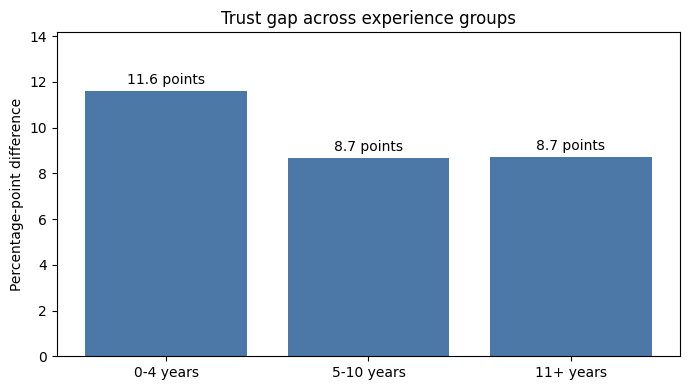

In [ ]:
# Plot the raw trust-versus-distrust difference in each experience group
experience_gap = subgroup_rates["Trust"] - subgroup_rates["Distrust"]

plt.figure(figsize=(7, 4))
bars = plt.bar(experience_gap.index, experience_gap.values, color="#4C78A8")
plt.bar_label(bars, fmt="%.1f points", padding=3)
plt.ylabel("Percentage-point difference")
plt.title("Trust gap across experience groups")
plt.ylim(0, experience_gap.max() * 1.22)
plt.tight_layout()
plt.show()

In [ ]:
# Collect the directly comparable models in one table
comparison_models = {
    "Main model": model,
    "Add predictive analytics": alternative_models["BroadTaskUse"],
    "Code review only": alternative_models["CodeReviewUse"],
    "Deployment only": alternative_models["DeploymentUse"],
    "Predictive analytics only": alternative_models["PredictiveUse"],
    "Complete cases": complete_case_model,
    "Trust and policy only": minimal_model,
    "Experience capped": capped_experience_model,
    "Small categories combined": collapsed_category_model
}

stability_rows = []
for name, fitted_model in comparison_models.items():
    stability_rows.append(odds_ratio_row(
        fitted_model, trust_term, name, "Highly trust vs. neutral"
    ))
    stability_rows.append(odds_ratio_row(
        fitted_model, policy_term, name, "Reported policy gap"
    ))

stability_results = pd.DataFrame(stability_rows)
stability_results.round(3)

,Analysis,Relationship,Odds ratio,CI low,CI high,p-value
0,Main model,Highly trust vs. neutral,1.617,1.283,2.037,0.000
1,Main model,Reported policy gap,1.023,0.946,1.107,0.564
2,Add predictive analytics,Highly trust vs. neutral,1.576,1.260,1.972,0.000
3,Add predictive analytics,Reported policy gap,1.032,0.958,1.111,0.409
4,Code review only,Highly trust vs. neutral,1.469,1.153,1.872,0.002
5,Code review only,Reported policy gap,1.002,0.922,1.090,0.955
6,Deployment only,Highly trust vs. neutral,2.517,1.836,3.451,0.000
7,Deployment only,Reported policy gap,1.126,0.981,1.294,0.092
8,Predictive analytics only,Highly trust vs. neutral,2.125,1.556,2.901,0.000
9,Predictive analytics only,Reported policy gap,1.171,1.030,1.331,0.016


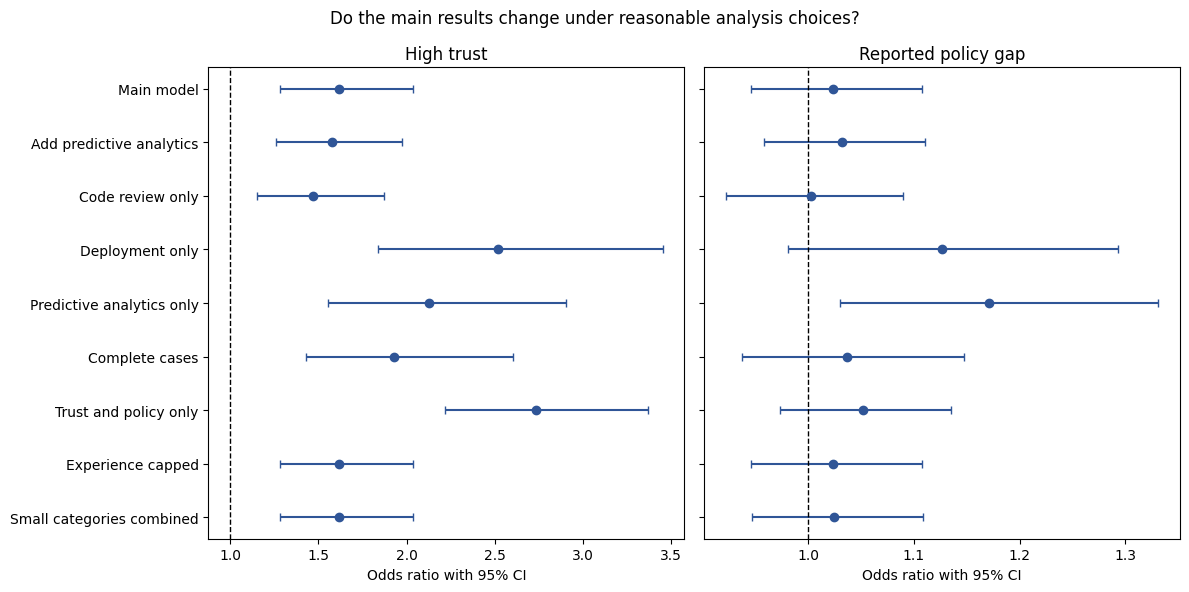

In [ ]:
# Final sensitivity figure: estimates should be read against the line at 1
figure_data = stability_results.copy()
analysis_order = list(comparison_models)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for axis, relationship, title in zip(
    axes,
    ["Highly trust vs. neutral", "Reported policy gap"],
    ["High trust", "Reported policy gap"]
):
    current = figure_data[figure_data["Relationship"] == relationship].copy()
    current["Analysis"] = pd.Categorical(
        current["Analysis"], categories=analysis_order, ordered=True
    )
    current = current.sort_values("Analysis", ascending=False)
    errors = [
        current["Odds ratio"] - current["CI low"],
        current["CI high"] - current["Odds ratio"]
    ]
    axis.errorbar(current["Odds ratio"], current["Analysis"],
                  xerr=errors, fmt="o", capsize=3, color="#2F5597")
    axis.axvline(1, color="black", linestyle="--", linewidth=1)
    axis.set_title(title)
    axis.set_xlabel("Odds ratio with 95% CI")

fig.suptitle("Do the main results change under reasonable analysis choices?")
plt.tight_layout()
plt.savefig("sensitivity_analysis_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Count how often the direction and confidence-interval conclusions agree
trust_checks = stability_results[
    stability_results["Relationship"] == "Highly trust vs. neutral"
]
policy_checks = stability_results[
    stability_results["Relationship"] == "Reported policy gap"
]

print("High-trust odds ratios above 1:",
      (trust_checks["Odds ratio"] > 1).sum(), "of", len(trust_checks))
print("High-trust confidence intervals above 1:",
      (trust_checks["CI low"] > 1).sum(), "of", len(trust_checks))
print("Policy confidence intervals containing 1:",
      ((policy_checks["CI low"] <= 1) & (policy_checks["CI high"] >= 1)).sum(),
      "of", len(policy_checks))

High-trust odds ratios above 1: 9 of 9
High-trust confidence intervals above 1: 9 of 9
Policy confidence intervals containing 1: 8 of 9
